# Project Business Statistics: E-news Express

## Defining the Problem Statement and Objectives

**Defining the Problem**

E-news Express, an online news portal, faces a challenge in acquiring new subscribers. Despite the advantages of e-news like rapid updates and multimedia content, the company has noticed a decline in new monthly subscribers. This issue is attributed to the website's design, particularly its landing page, which may not effectively engage visitors. To address this, We need to understand E-news Express user behavior and their preferences better, especially regarding how users interact with their website. The main problem lies in determining the most effective webpage design that maximizes user engagement and encourages subscription.

**Defining the Objective**

The objective of this project is to evaluate the effectiveness of a newly designed landing page in increasing subscriber numbers for E-news Express. To achieve this, the Data Science team conducted an A/B test, comparing the new landing page with the existing one. This involved randomly dividing 100 users into two groups, with one group accessing the current page and the other the new one. The key goal is to analyze the data from this experiment to answer crucial questions: whether users spend more time on the new page, if the new page has a higher conversion rate, how the converted status relates to preferred language, and if there's a difference in time spent on the new page among users of different languages. The outcome of this analysis will guide the decision-making process on whether the new landing page is more effective in increasing subscriptions at a 5% significance level.

## Import all the necessary libraries

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns




## Reading the Data into a DataFrame

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/abtest.csv')

Mounted at /content/drive


## Explore the dataset and extract insights using Exploratory Data Analysis

- Data Overview
  - Viewing the first and last few rows of the dataset
  - Checking the shape of the dataset
  - Getting the statistical summary for the variables
- Check for missing values
- Check for duplicates

In [ ]:
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [ ]:
df.tail()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


In [ ]:
df.shape

(100, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [ ]:
statistical_summary = df.describe()
print(statistical_summary)

             user_id  time_spent_on_the_page
count     100.000000              100.000000
mean   546517.000000                5.377800
std        52.295779                2.378166
min    546443.000000                0.190000
25%    546467.750000                3.880000
50%    546492.500000                5.415000
75%    546567.250000                7.022500
max    546592.000000               10.710000


In [ ]:
categorical_columns = ['group', 'landing_page', 'converted', 'language_preferred']

for column in categorical_columns:
    print(f"Summary for {column}:")
    print(df[column].value_counts())
    print("\n")



Summary for group:
control      50
treatment    50
Name: group, dtype: int64


Summary for landing_page:
old    50
new    50
Name: landing_page, dtype: int64


Summary for converted:
yes    54
no     46
Name: converted, dtype: int64


Summary for language_preferred:
Spanish    34
French     34
English    32
Name: language_preferred, dtype: int64




In [ ]:
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64


In [ ]:
duplicates = df[df.duplicated()]
print("Duplicate rows in the DataFrame:")
print(duplicates)

Duplicate rows in the DataFrame:
Empty DataFrame
Columns: [user_id, group, landing_page, time_spent_on_the_page, converted, language_preferred]
Index: []


### Univariate Analysis

**Time Spent on the Page:**


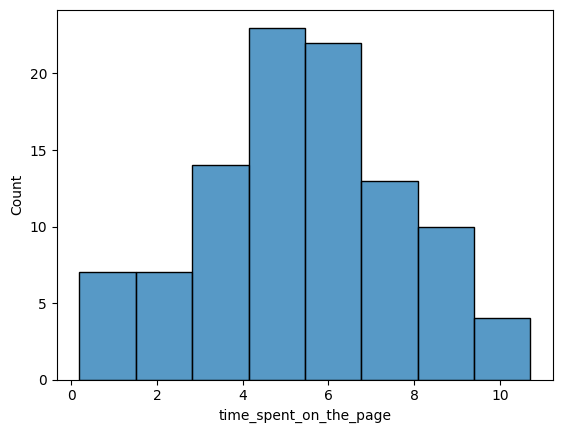

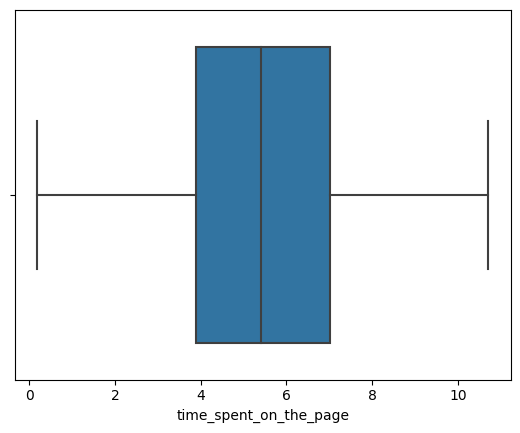

In [ ]:
sns.histplot(data=df,x='time_spent_on_the_page')
plt.show()
sns.boxplot(data=df,x='time_spent_on_the_page')
plt.show()

**Group:**

In [ ]:
df['group'].value_counts()

control      50
treatment    50
Name: group, dtype: int64

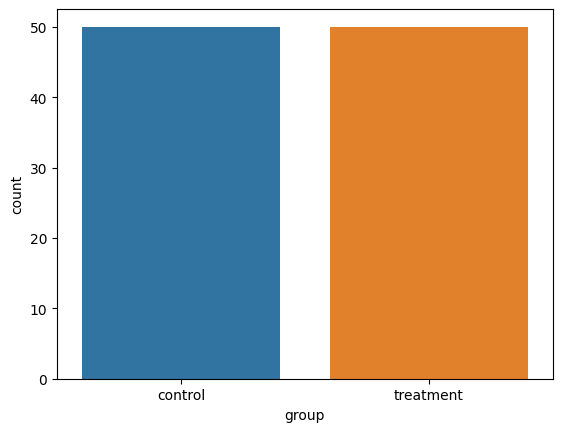

In [ ]:
sns.countplot(data=df,x='group')
plt.show()

**Landing Page:**

In [ ]:
df['landing_page'].value_counts()

old    50
new    50
Name: landing_page, dtype: int64

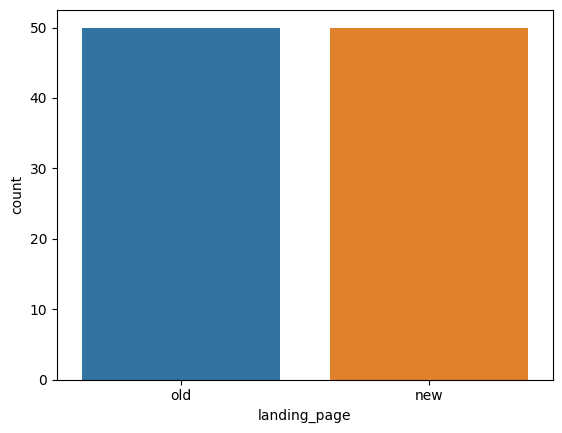

In [ ]:
sns.countplot(data=df, x='landing_page')
plt.show()

**Converted:**

In [ ]:
df['converted'].value_counts()

yes    54
no     46
Name: converted, dtype: int64

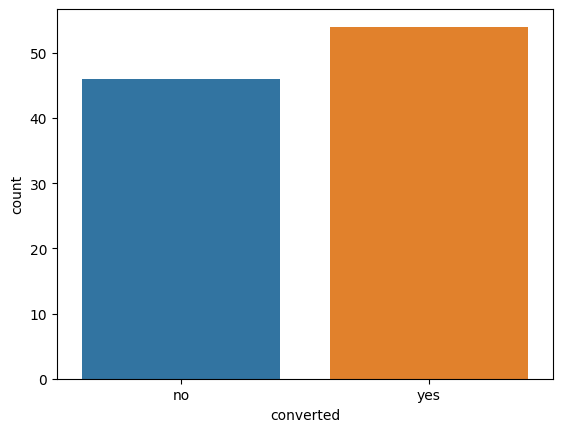

In [ ]:
sns.countplot(data=df, x='converted')
plt.show()

**Language Preferred:**

In [ ]:
df['language_preferred'].value_counts()

Spanish    34
French     34
English    32
Name: language_preferred, dtype: int64

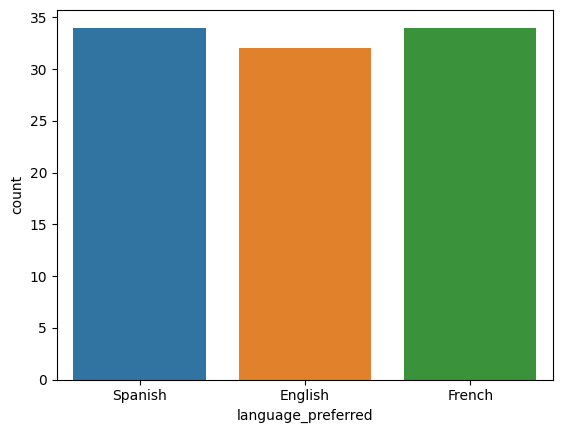

In [ ]:
sns.countplot(data=df,x='language_preferred')
plt.show()

### Bivariate Analysis

**Landing page vs Time spent on the page:**

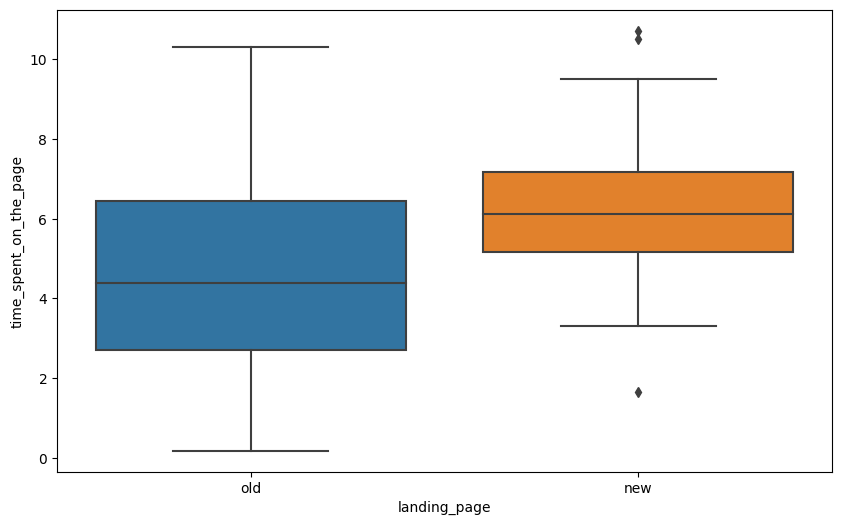

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='landing_page',y='time_spent_on_the_page')
plt.show()

**Conversion status vs Time spent on the page:**

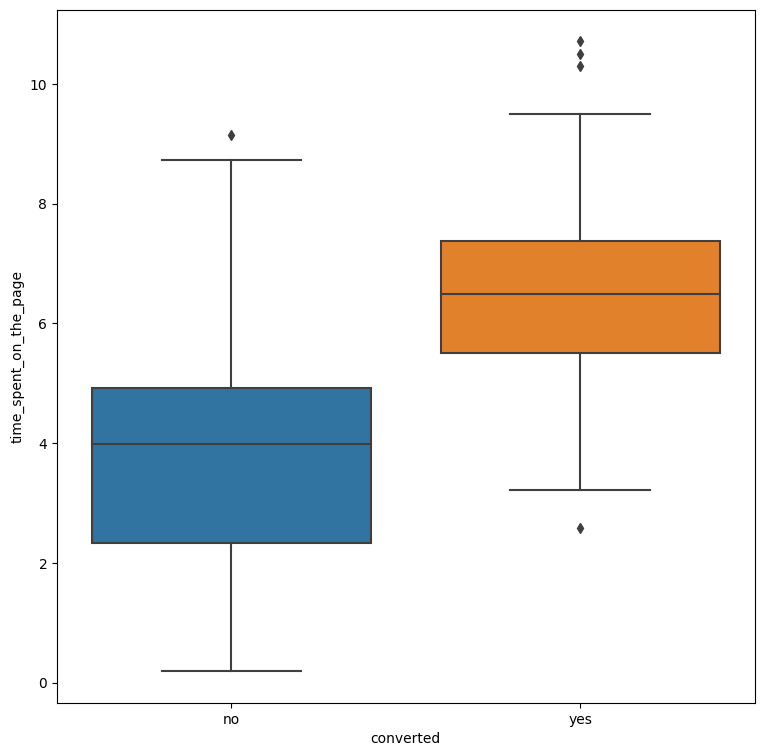

In [ ]:
plt.figure(figsize=(9, 9))
sns.boxplot(data = df, x = 'converted', y ='time_spent_on_the_page')
plt.show()

**Language preferred vs Time spent on the page:**

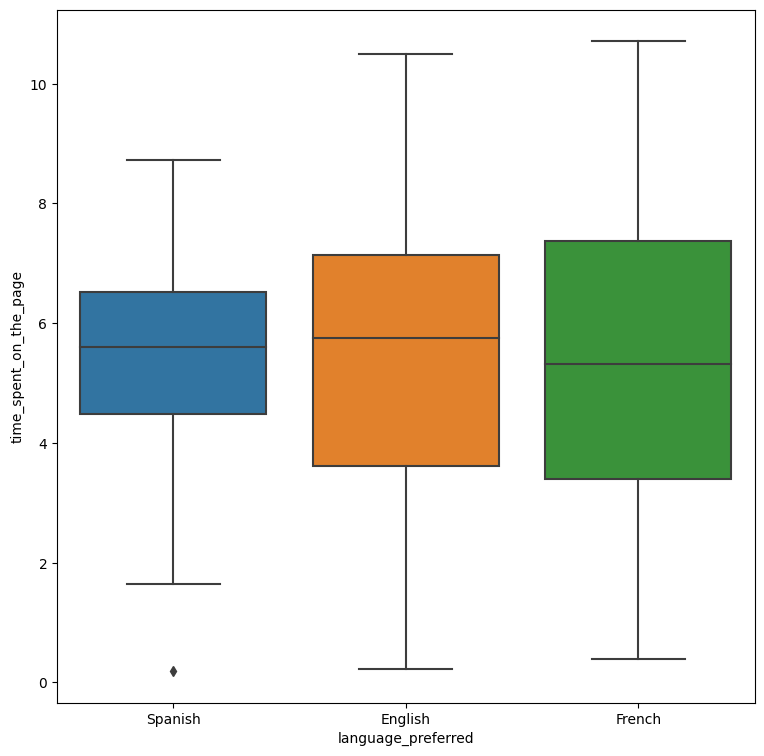

In [ ]:
plt.figure(figsize=(9, 9))
sns.boxplot(data = df, x = 'language_preferred', y ='time_spent_on_the_page')
plt.show()

## 1. Do the users spend more time on the new landing page than the existing landing page?

### Perform Visual Analysis

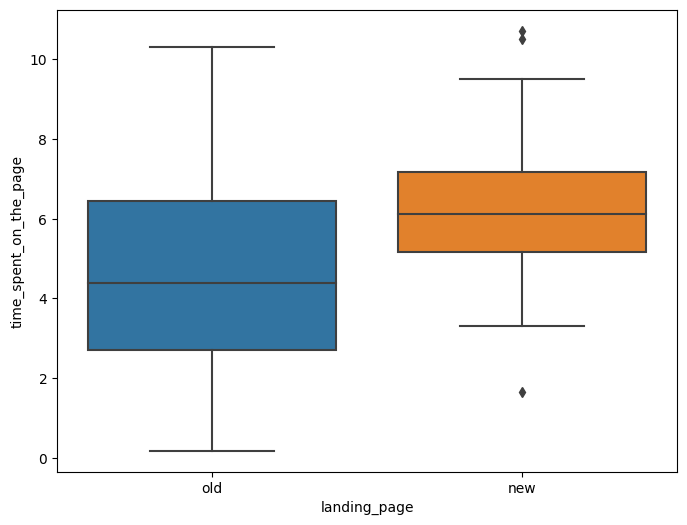

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x = 'landing_page', y = 'time_spent_on_the_page', data = df)
plt.show()

### Step 1: Define the null and alternate hypotheses

$H_0$: *μ new ≤ μ old*

The mean time spent on the New landing page is less than or equal to the mean time spent on the existing landing page.

$H_a$: *μ new > μ old*

The mean time spent on the New Landing Page is greater than the mean time spent on the existing landing page.


### Step 2: Select Appropriate test

**Two-sample t-test** because we are comparing two population means from two independent populations and the standard deviations are unknown.

### Step 3: Decide the significance level

**α=0.05 .**


### Step 4: Collect and prepare data

In [ ]:

time_spent_new = df[df['landing_page'] == 'new']['time_spent_on_the_page']


time_spent_old = df[df['landing_page'] == 'old']['time_spent_on_the_page'] 

In [ ]:
print('The sample standard deviation of the time spent on the new page is:', round(time_spent_new.std(),2))
print('The sample standard deviation of the time spent on the new page is:', round(time_spent_old.std(),2))

The sample standard deviation of the time spent on the new page is: 1.82
The sample standard deviation of the time spent on the new page is: 2.58


### Step 5: Calculate the p-value

In [ ]:
from scipy.stats import ttest_ind

In [41]:
test_stat, p_value = ttest_ind(time_spent_new, time_spent_old, equal_var=False, alternative='greater')

print('The p-value is', p_value)

The p-value is 0.0001392381225166549


### Step 6: Compare the p-value with $\alpha$

In [ ]:
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value 0.0001392381225166549 is less than the level of significance, we reject the null hypothesis.


### Step 7:  Draw inference

**Results**:
The p-value obtained (0.0001392381225166549) is extremely low. This strongly suggests that the observed difference in the time spent on the new and old landing pages is not due to random chance.The null hypothesis, which posits no difference or lesser time spent on the new page compared to the old page, is rejected.

**Is the New Landing Page more Effective?**
The rejection of the null hypothesis implies that the new landing page is statistically more effective in engaging users, as evidenced by the increased time spent on it. This suggests that the design and content of the new page are more appealing and engaging.

**Business Implications:**
From a business standpoint, the longer duration users spend on the new landing page may indicate higher engagement levels. This is a positive development since higher engagement can lead to a greater likelihood of users converting into subscribers.
Based on these results, E-news Express could consider rolling out the new landing page to all users, with the expectation that it could boost overall engagement and conversion rates.

**What should we consider?**
While the increased time spent is encouraging, it's important to also consider other metrics such as conversion rates, bounce rates, and user feedback for a more rounded assessment of the new page's performance.
Further studies could look into how different user segments respond to the new landing page versus the old one, possibly focusing on factors like demographics and language preferences.

**What should we be careful about the interpretation?** It's crucial to distinguish between statistical significance and practical significance. The business must assess whether the increase in time spent on the page is substantial and meaningful enough to warrant changes in web design and content strategy.
The findings are based on the sample and experimental conditions used. It's essential to ensure that the sample is representative of the broader user base for the results to be generalizable.

**A similar approach can be followed to answer the other questions.**

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

**Visual Analysis**

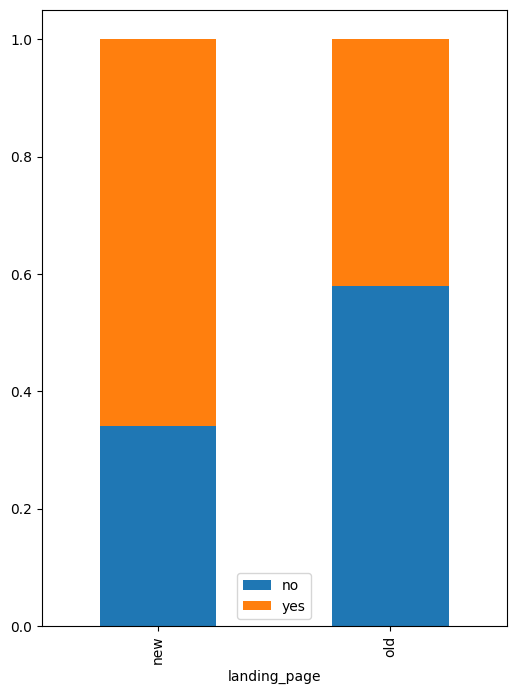

In [42]:
pd.crosstab(df['landing_page'],df['converted'],normalize='index').plot(kind="bar", figsize=(6,8),stacked=True)
plt.legend()
plt.show()

**Step 1: Define Null and Alternate Hypotheses**

H0: The conversion rate for the new landing page is less than or equal to that of the old landing page.

H1: The conversion rate for the new landing page is greater than that of the old landing page.

**Step 2: Select Appropriate Test**

Two-proportion z-test

**Step 3: Decide the Significance Level**

α: 0.05

**Step 4: Collect and Prepare Data**

In [43]:
new_converted = df[df['group'] == 'treatment']['converted'].value_counts()['yes']

old_converted = df[df['group'] == 'control']['converted'].value_counts()['yes'] 

n_control = df.group.value_counts()['control'] 
n_treatment = df.group.value_counts()['treatment'] 

print('The numbers of users served the new and old pages are {0} and {1} respectively'.format(n_control, n_treatment ))

The numbers of users served the new and old pages are 50 and 50 respectively


**Step 5: Calculate the p-value**

In [44]:
from statsmodels.stats.proportion import proportions_ztest

test_stat, p_value = proportions_ztest([new_converted, old_converted] , [n_treatment, n_control], alternative ='larger')   

print('The p-value is', p_value)

The p-value is 0.008026308204056278


**Step 6: Compare the p-value with α**

In [45]:
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value 0.008026308204056278 is less than the level of significance, we reject the null hypothesis.


**Step 7: Draw Inference**

**Results**:
The statistical analysis, including a Two-proportion z-test, has led to a significant finding. With a p-value of 0.008026308204056278, which is lower than the conventional significance level of 0.05, the null hypothesis is rejected.
This rejection of the null hypothesis suggests that the new landing page has a significantly higher conversion rate compared to the old page.

**Business Implications:**
For E-news Express, this result is a strong indicator that the new landing page could be more effective in converting visitors into subscribers.
The decision to implement the new landing page across the website is now backed by statistical evidence of its effectiveness in terms of conversion rates.

**What should we considerations for a comprehensive decision?**
While the improved conversion rate is promising, it's important to consider this result in the context of other performance metrics. These include user engagement, time spent on the page, bounce rate, and qualitative user feedback.
A holistic approach that integrates these various metrics will provide a more complete picture of the new landing page's overall effectiveness.

**Practical Significance of the Data:**
The practical implications of this statistically significant result should be carefully evaluated. It's vital to assess if the increase in conversion rate will have a meaningful impact on the business goals and objectives.
A statistically significant improvement in conversion rate should translate into tangible business benefits for it to be considered a success.

## 3. Is the conversion and preferred language are independent or related?

**Perform Visual Analysis**

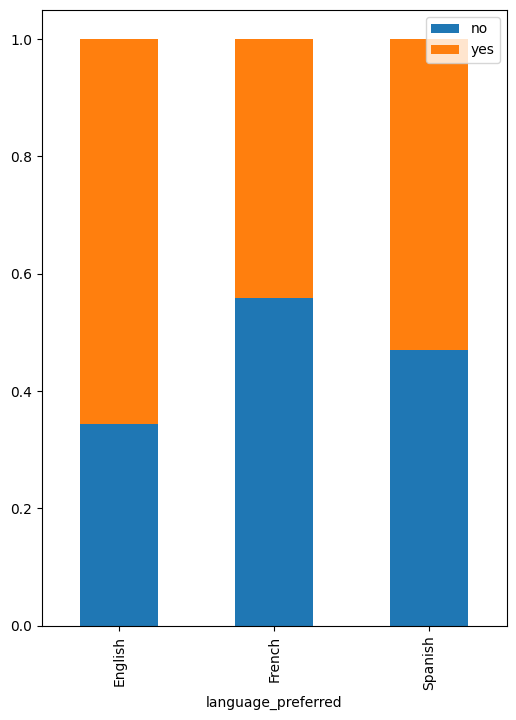

In [46]:
pd.crosstab(df['language_preferred'],df['converted'],normalize='index').plot(kind="bar", figsize=(6,8), stacked=True)
plt.legend()
plt.show()

**Step 1: Define the null and alternate hypotheses**

H0: The converted status is independent of the preferred language.

H1: The converted status depends on the preferred language.

**Step 2: Select Appropriate test**

Chi-square test of independence.

**Step 3: Decide the significance level**

α = 0.05.

**Step 4: Collect and prepare data**

In [50]:
contingency_table = pd.crosstab(df['language_preferred'], df['converted'])

contingency_table

converted,no,yes
language_preferred,,
English,11,21
French,19,15
Spanish,16,18


**Step 5: Calculate the p-value**

In [48]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, exp_freq = chi2_contingency(contingency_table)

print('The p-value is', p_value)


The p-value is 0.2129888748754345


**Step 6: Compare the p-value with α**

In [49]:
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')


As the p-value 0.2129888748754345 is greater than the level of significance, we fail to reject the null hypothesis.


**Step 7: Draw inference**

**Results:**
A Chi-square test was conducted to explore if there's a relationship between the conversion status of users and their preferred language. With a p-value of 0.2129888748754345, which is greater than the standard significance level of 0.05, the test results suggest that there is no statistically significant association between a user's language preference and their likelihood of converting Since the p-value is higher than 0.05, the null hypothesis is not rejected, meaning that there's no strong evidence to suggest that the language a user prefers has a significant impact on their decision to subscribe.

**Business Implications**
E-news Express might not need to prioritize language-specific content customization as a key strategy for increasing conversion rates. The focus could instead shift to other factors that might have a more significant impact on user conversion rates.

**What should we consider?**
It's important for E-news Express to consider these results in the context of their overall strategy. Other aspects like content quality, user experience, and market trends might be more crucial in driving subscriptions.
If language preference is not a major factor in conversions, the company could explore other potential influences that might be more effective in increasing subscriber numbers.

**Conclusion:**
This analysis suggests that language preference doesn't play a major role in influencing user conversions for E-news Express. The company can use this insight to guide their content strategy and explore other areas that might be more impactful for improving conversion rates.

## 4. Is the time spent on the new page same for the different language users?

**Perform Visual Analysis**

In [51]:
df_new = df[df['landing_page'] == 'new']

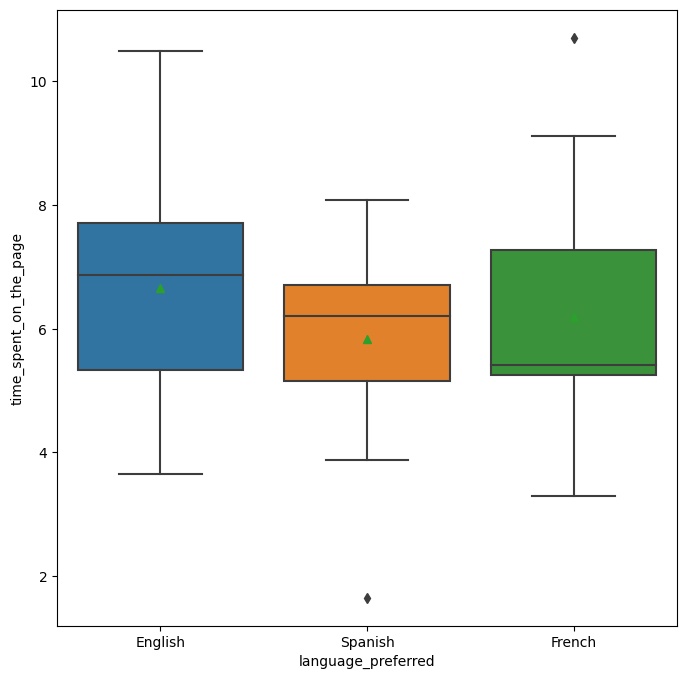

In [52]:
plt.figure(figsize=(8,8))
sns.boxplot(x = 'language_preferred', y = 'time_spent_on_the_page', showmeans = True, data = df_new)
plt.show()

In [53]:
df_new.groupby(['language_preferred'])['time_spent_on_the_page'].mean()

language_preferred
English    6.663750
French     6.196471
Spanish    5.835294
Name: time_spent_on_the_page, dtype: float64

**Step 1: Define the null and alternate hypotheses**

H0: The mean time spent on the new landing page is the same across all language groups.

H1: The mean time spent on the new landing page differs among language groups.

**Step 2: Select Appropriate test**

ANOVA Test

**Step 3: Decide the significance level**

α = 0.05.

**Step 4: Collect and prepare data**

In [54]:
time_spent_English = df_new[df_new['language_preferred']=="English"]['time_spent_on_the_page']

time_spent_French = df_new[df_new['language_preferred'] == 'French']['time_spent_on_the_page']

time_spent_Spanish = df_new[df_new['language_preferred'] == 'Spanish']['time_spent_on_the_page']

print("Mean time spent on the new page by English language users:", time_spent_English.mean())

print("Mean time spent on the new page by French language users:", time_spent_French.mean())

print("Mean time spent on the new page by Spanish language users:", time_spent_Spanish.mean())


Mean time spent on the new page by English language users: 6.66375
Mean time spent on the new page by French language users: 6.196470588235294
Mean time spent on the new page by Spanish language users: 5.835294117647059


In [55]:
df_old = df[df['landing_page'] == 'old']

time_spent_old_English = df_old[df_old['language_preferred'] == "English"]['time_spent_on_the_page'].mean()
time_spent_old_French = df_old[df_old['language_preferred'] == "French"]['time_spent_on_the_page'].mean()
time_spent_old_Spanish = df_old[df_old['language_preferred'] == "Spanish"]['time_spent_on_the_page'].mean()

print("Mean time spent on the old page by English language users:", time_spent_old_English)
print("Mean time spent on the old page by French language users:", time_spent_old_French)
print("Mean time spent on the old page by Spanish language users:", time_spent_old_Spanish)


Mean time spent on the old page by English language users: 4.454375
Mean time spent on the old page by French language users: 4.309999999999999
Mean time spent on the old page by Spanish language users: 4.828235294117648


**Step 5: Calculate the p-value**

In [56]:
from scipy.stats import f_oneway

test_stat, p_value = f_oneway(time_spent_English, time_spent_French, time_spent_Spanish)

print('The p-value is', p_value)


The p-value is 0.43204138694325955


**Step 6: Compare the p-value with α**

In [57]:
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')


As the p-value 0.43204138694325955 is greater than the level of significance, we fail to reject the null hypothesis.


**Step 7: Draw inference**

**Results**
An ANOVA test was used to check if users of English, French, and Spanish languiages spent different amounts of time on the new landing page. The p-value from this test is 0.43204138694325955, which is higher than the standard significance level of 0.05.Since the p-value is more than 0.05, the null hypothesis, which suggests no difference in time spent on the new page across different language groups, is not rejected. Meaning that whether a user prefers English, French, or Spanish does not significantly affect how long they stay on the new landing page.

**Business Implications:**
The findings suggest that the new landing page is equally engaging to users regardless of their language preference. This could mean that E-news Express might not need to create language-specific versions of the new page.
Other factors, like content type, design, and overall user experience, may be more important to focus on for enhancing user engagement.

**What should we consider?:**
While language doesn't significantly affect the time spent on the new page, it's still important to consider other aspects that could influence user experience and engagement. It's important to view these results in the context of overall user behavior and business goals. Understanding user preferences in detail can still provide valuable insights for optimizing the user experience.  The focus of this analysis was language preference, but other factors like demographics or user behaviors could also play a role in how users interact with the site and should be explored.

**Conclusion:** This analysis indicates that language preference doesn't have a significant impact on the amount of time users spend on the new landing page, suggesting a consistent user experience across different language groups. This insight can inform E-news Express's content strategy and broader user engagement efforts.

## Conclusion and Business Recommendations

**Conclusions**

Time Spent on New vs. Old Landing Page:

- Users spend more time on the new landing page than the old one, indicating that the new page is more engaging.

Conversion Rate on New vs. Old Landing Page:

- The conversion rate on the new page isn't significantly higher than the old page, meaning the new page's increased engagement doesn't necessarily lead to more subscribers.

Conversion Status and Preferred Language:

- There's no significant link between a user's language preference and their likelihood of subscribing, showing that language doesn't heavily influence conversion.

Time Spent on New Page by Language Preference:

- No significant difference in time spent on the new page across English, French, and Spanish, suggesting a consistent experience for all language groups.

**Business Recommendations**

Implement the New Landing Page:

- Given its higher engagement levels, rolling out the new landing page could improve user satisfaction and retention.

Further Optimize Conversion Strategies:

- Despite more time spent on the new page, its similar conversion rate to the old page suggests the need for further optimization, like testing different calls-to-action or personalized content.

Language-Specific Content Strategy:

- Since language preference doesn’t significantly affect engagement or conversion, a heavy focus on language-specific content for the landing page might not be necessary. However, offering content in multiple languages can still be beneficial for accessibility.

Holistic User Experience Analysis:

- Conduct further research on factors like UI design, content relevance, and ease of navigation to understand what else influences user engagement and conversion.

Monitor and Iterate:

- Continuously track performance metrics and user feedback to keep improving the landing page and other website aspects.

Broader Market Strategy:

- Look beyond the landing page and consider strategies across social media, email marketing, and other channels to attract and retain subscribers.

**What else should we consider?**

Integration with Marketing Campaigns:

- Analyze how different marketing campaigns and traffic sources affect user behavior on the landing page.

Long-Term Analysis:

- Consider a long-term study to see how user behavior and conversion rates evolve with the new landing page over time.

By following these recommendations, E-news Express can strengthen its online presence, enhance user engagement, and potentially grow its subscriber base.

___